In [1]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from tqdm import tqdm

# CONFIG

In [2]:
SEED = 42
NFOLDS = 5 #changed
MAX_LEN = 256//2
BATCH_SIZE = 16*2*2
EPOCHS = 10 #changed
MODEL_PATH2 = "/kaggle/input/deberta-v3-base/transformers/default/1/deberta-v3-base"
MODEL_PATH='/kaggle/input/deberta-v3-small/transformers/default/1'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Set seeds
import random
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
# Load and preprocess data
train_path = "/kaggle/input/jigsaw-agile-community-rules/train.csv"
test_path = "/kaggle/input/jigsaw-agile-community-rules/test.csv"
sample_sub_path = "/kaggle/input/jigsaw-agile-community-rules/sample_submission.csv"

In [6]:
df = pd.read_csv(train_path)
df["text"] = df["rule"] + " [SEP] " + df["body"]
df["label"] = df["rule_violation"].astype(float)

In [7]:
unlabelled_path='/kaggle/input/jigsaw-2m-reddit-unlabelled/reddit-removal-log.csv'
unlabelled_df = pd.read_csv(unlabelled_path)

In [8]:
def add_data(dataframe):
    ret=[[],[]]
    for i in ['positive_example_1','positive_example_2','negative_example_1','negative_example_2']:
        tmp= (dataframe['rule']+' [SEP] '+ dataframe[i]).tolist()
        ret[0]+= tmp
        ret[1]+= [1]*len(tmp) if 'positive' in i else [0]*len(tmp)
    return ret

In [9]:
test_df = pd.read_csv(test_path)

# Get augmented data from both df and test_df
augmented_train = add_data(df)
augmented_test = add_data(test_df)

# Combine original df with augmented data
augmented_texts =  df.text.tolist()+augmented_train[0] + augmented_test[0]
augmented_labels =  df.label.tolist()+augmented_train[1] + augmented_test[1]


# Create new augmented dataframe
augmented_df = pd.DataFrame({
    'text': augmented_texts,
    'label': augmented_labels
})
print(f'Before:{augmented_df.shape}')
augmented_df = augmented_df.groupby(augmented_df['text'].str.lower(), as_index=False).agg({
    'text': 'first',  # Keep the original case of the first occurrence
    'label': 'mean'   # Take mean of labels
})
print('After:',augmented_df.shape)
augmented_df['rule']= augmented_df.text.apply(lambda x: x.split(' [SEP] ')[0])
augmented_df['body']= augmented_df.text.apply(lambda x: x.split(' [SEP] ')[1])

rule_map= {i:j for j,i in enumerate(augmented_df.rule.str.lower().unique())}
augmented_df['rule_id']= augmented_df.rule.str.lower().map(rule_map)

augmented_df.head()

Before:(10185, 2)
After: (1875, 2)


,text,label,rule,body,rule_id
0,"No Advertising: Spam, referral links, unsolici...",1.0,"No Advertising: Spam, referral links, unsolici...","\n\nIf you have some free time on your hands, ...",0
1,"No Advertising: Spam, referral links, unsolici...",1.0,"No Advertising: Spam, referral links, unsolici...",\n\nplease visit http://www.shifadental.net/te...,0
2,"No Advertising: Spam, referral links, unsolici...",0.0,"No Advertising: Spam, referral links, unsolici...",\n\nSD | [ English Stream 1 Arsenal vs Tottenh...,0
3,"No Advertising: Spam, referral links, unsolici...",0.0,"No Advertising: Spam, referral links, unsolici...",\n**HD** ENG [ 1080P HD Amazing] :- [USTREAM E...,0
4,"No Advertising: Spam, referral links, unsolici...",1.0,"No Advertising: Spam, referral links, unsolici...",\nFree http://forums.airdroid.com/viewtopic.ph...,0


In [10]:
# Load tokenizer locally
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast = False)

In [11]:
# print(df.head())
# print(df.columns.tolist())

In [12]:
class JigsawDataset(Dataset):
    def __init__(self, texts, labels,rule_ids, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.rule_ids = rule_ids

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text, padding='max_length', truncation=True, max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        item['rule_ids']= torch.tensor(self.rule_ids[idx])
        return item

In [13]:
class JigsawModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()
        self.base = AutoModel.from_pretrained(model_path)
        self.drop = nn.Dropout(0.15)
        self.out = nn.Linear(self.base.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]
        return self.out(self.drop(pooled)).squeeze(1)

In [14]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        logits = model(input_ids, mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [15]:
def validate(model, loader):
    model.eval()
    preds, targets, rule_ids_list = [], [], []
    total_loss = 0
    criterion = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            rule_ids = batch["rule_ids"]  # Assuming this is already on CPU as integers
            
            logits = model(input_ids, mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(labels.cpu().numpy())
            rule_ids_list.extend(rule_ids.cpu().numpy() if torch.is_tensor(rule_ids) else rule_ids)
    
    # Convert to numpy arrays
    preds = np.array(preds)
    targets = np.array(targets)
    rule_ids_array = np.array(rule_ids_list)
    
    # Compute AUC per rule
    unique_rules = np.unique(rule_ids_array)
    rule_aucs = {}
    
    for rule_id in unique_rules:
        rule_mask = rule_ids_array == rule_id
        rule_preds = preds[rule_mask]
        rule_targets = targets[rule_mask]
        
        # Only compute AUC if we have both positive and negative samples for this rule
        if len(np.unique(rule_targets >= 0.5)) > 1:
            rule_auc = roc_auc_score(rule_targets >= 0.5, rule_preds)
            rule_aucs[rule_id] = rule_auc
        else:
            # If only one class present, we can't compute AUC
            rule_aucs[rule_id] = np.nan
    
    # Compute average AUC across rules (excluding NaN values)
    valid_aucs = [auc for auc in rule_aucs.values() if not np.isnan(auc)]
    avg_auc_per_rule = np.mean(valid_aucs) if valid_aucs else 0
    
    val_loss = total_loss / len(loader)
    # print(rule_aucs,'Rule_AUC')
    return avg_auc_per_rule, val_loss, preds,targets #XXX

In [16]:
from transformers import get_linear_schedule_with_warmup

In [17]:
import math

In [18]:
import gc;gc.collect()
torch.cuda.memory.empty_cache()

In [ ]:
if not os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    # STAGE 1: Train models for pseudo labeling
    print("=== STAGE 1: Training models for pseudo labeling ===")
    
    stage1_models = []
    oof=[]
    val_id=[]
    folds = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)
    
    for fold, (tr_idx, val_idx) in enumerate(folds.split(augmented_df, augmented_df["rule"])):
        print(f'--------- FOLD {fold} (Stage 1) --------')
        torch.cuda.empty_cache()
        gc.collect()
        
        val_ds = JigsawDataset(
            augmented_df.iloc[val_idx]['text'].tolist(), 
            augmented_df.iloc[val_idx]['label'].tolist(), 
            augmented_df.iloc[val_idx]['rule_id'].tolist(), 
            tokenizer, MAX_LEN
        )
    
        train_ds = JigsawDataset(
            augmented_df.iloc[tr_idx]['text'].tolist(), 
            augmented_df.iloc[tr_idx]['label'].tolist(), 
            augmented_df.iloc[tr_idx]['rule_id'].tolist(), 
            tokenizer, MAX_LEN
        )
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

        model = JigsawModel(MODEL_PATH2).to(DEVICE)
        for name, param in model.named_parameters():
            if name.startswith('base.embedding'):
                param.requires_grad = False
                # print(name)
        model= nn.DataParallel(model)

        model.load_state_dict(torch.load(f"/kaggle/input/jigsaw/model_fold{fold}.bin", map_location=DEVICE))
        print('Trainable Params: ',sum(i.numel() for i in model.parameters() if i.requires_grad))
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-6)
        total_steps = EPOCHS * len(train_loader)
        warmup_steps = int(0.1 * total_steps)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
    
        # best_auc = 0
        # for epoch in range(EPOCHS):
        #     print(f"Epoch {epoch+1}/{EPOCHS}")
        #     loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        val_auc, val_loss, val_preds,targets = validate(model, val_loader) #XXX
            
        #     print(f"Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")
        #     if val_auc > best_auc:
        #         best_auc = val_auc
        #         model_to_save = model.module if hasattr(model, 'module') else model
        #         torch.save(model_to_save.state_dict(), f"model_fold{fold}_stage1.bin")
        val_id.extend(list(val_idx))
        oof.append((val_preds,targets))
        stage1_models.append(f"model_fold{fold}_stage1.bin")
        del model, optimizer, scheduler, train_ds, val_ds, train_loader, val_loader

=== STAGE 1: Training models for pseudo labeling ===
--------- FOLD 0 (Stage 1) --------
Trainable Params:  85449985
--------- FOLD 1 (Stage 1) --------
Trainable Params:  85449985


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

# Assuming oof contains tuples of (predictions, targets)
# Concatenate all folds
all_preds_raw = np.concatenate([x[0] for x in oof])
all_targets_raw = np.concatenate([x[1] for x in oof])

all_targets=np.zeros_like(all_targets_raw)
all_targets[val_id]= all_targets_raw

all_preds=np.zeros_like(all_preds_raw)
all_preds[val_id]= all_preds_raw

bert_preds= all_preds
all_targets=(all_targets>.5).astype(dtype=np.int8)
# Create analysis dataframe
df_analysis = pd.DataFrame({
    'prediction': all_preds,
    'target': all_targets,
    'confidence': np.abs(all_preds - 0.5) * 2,  # 0 = uncertain, 1 = confident
    'error': np.abs(all_preds - all_targets)
})

# Binary predictions
df_analysis['pred_class'] = (df_analysis['prediction'] > 0.5).astype(int)
df_analysis['correct'] = (df_analysis['pred_class'] == df_analysis['target']).astype(int)

print("="*80)
print("MODEL PERFORMANCE ANALYSIS")
print("="*80)

# Overall metrics
overall_auc = roc_auc_score(all_targets, all_preds)
print(f"\nOverall AUC: {overall_auc:.4f}")
print(f"Overall Accuracy: {df_analysis['correct'].mean():.4f}")

# 1. CONFIDENCE-BASED ANALYSIS
print("\n" + "="*80)
print("1. CONFIDENCE BINS ANALYSIS")
print("="*80)

# Create confidence bins
df_analysis['confidence_bin'] = pd.cut(df_analysis['confidence'], 
                                        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                        labels=['Very Uncertain', 'Uncertain', 'Moderate', 'Confident', 'Very Confident'])

confidence_stats = df_analysis.groupby('confidence_bin').agg({
    'correct': ['mean', 'count'],
    'error': 'mean',
    'target': 'mean'
}).round(4)

confidence_stats.columns = ['Accuracy', 'Count', 'Avg_Error', 'Positive_Rate']
print("\n", confidence_stats)

# 2. IDENTIFY CONFIDENTLY WRONG PREDICTIONS
print("\n" + "="*80)
print("2. CONFIDENTLY WRONG PREDICTIONS")
print("="*80)

# Define "confidently wrong" as high confidence but incorrect
confidently_wrong = df_analysis[(df_analysis['confidence'] > 0.7) & (df_analysis['correct'] == 0)]
print(f"\nTotal confidently wrong predictions: {len(confidently_wrong)} ({len(confidently_wrong)/len(df_analysis)*100:.2f}%)")

if len(confidently_wrong) > 0:
    print("\nConfidently Wrong Breakdown:")
    print(f"- False Positives (high confidence): {len(confidently_wrong[confidently_wrong['pred_class'] == 1])}")
    print(f"- False Negatives (high confidence): {len(confidently_wrong[confidently_wrong['pred_class'] == 0])}")
    print(f"- Average confidence of wrong predictions: {confidently_wrong['confidence'].mean():.4f}")

# 3. ANALYZE UNCERTAIN PREDICTIONS
print("\n" + "="*80)
print("3. UNCERTAIN PREDICTIONS ANALYSIS")
print("="*80)

uncertain = df_analysis[df_analysis['confidence'] < 0.3]
print(f"\nTotal uncertain predictions: {len(uncertain)} ({len(uncertain)/len(df_analysis)*100:.2f}%)")
print(f"Accuracy when uncertain: {uncertain['correct'].mean():.4f}")
print(f"Positive class rate when uncertain: {uncertain['target'].mean():.4f}")

# 4. ERROR ANALYSIS BY PREDICTION RANGE
print("\n" + "="*80)
print("4. ERROR PATTERNS BY PREDICTION RANGE")
print("="*80)

df_analysis['pred_range'] = pd.cut(df_analysis['prediction'], 
                                     bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                     labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

range_stats = df_analysis.groupby('pred_range').agg({
    'correct': ['mean', 'count'],
    'target': 'mean'
}).round(4)

range_stats.columns = ['Accuracy', 'Count', 'True_Positive_Rate']
print("\n", range_stats)

# 5. CALIBRATION ANALYSIS
print("\n" + "="*80)
print("5. CALIBRATION ANALYSIS")
print("="*80)

prob_true, prob_pred = calibration_curve(all_targets, all_preds, n_bins=10)
calibration_error = np.mean(np.abs(prob_true - prob_pred))
print(f"\nExpected Calibration Error (ECE): {calibration_error:.4f}")
print("(Lower is better - measures if predicted probabilities match true probabilities)")

# 6. CONFUSION MATRIX ANALYSIS
print("\n" + "="*80)
print("6. CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(all_targets, df_analysis['pred_class'])
print("\n", pd.DataFrame(cm, 
                         columns=['Pred Negative', 'Pred Positive'],
                         index=['True Negative', 'True Positive']))

# 7. DETAILED CLASSIFICATION REPORT
print("\n" + "="*80)
print("7. CLASSIFICATION REPORT")
print("="*80)
print("\n", classification_report(all_targets, df_analysis['pred_class'], 
                                   target_names=['Negative', 'Positive']))

# VISUALIZATION SECTION
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Weakness Analysis', fontsize=16, fontweight='bold')

# Plot 1: Confidence vs Accuracy
ax1 = axes[0, 0]
conf_acc = df_analysis.groupby(pd.cut(df_analysis['confidence'], bins=20))['correct'].mean()
conf_bins = [interval.mid for interval in conf_acc.index]
ax1.plot(conf_bins, conf_acc.values, marker='o', linewidth=2)
ax1.set_xlabel('Confidence', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy vs Confidence Level', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=df_analysis['correct'].mean(), color='r', linestyle='--', label='Overall Accuracy')
ax1.legend()

# Plot 2: Prediction Distribution
ax2 = axes[0, 1]
ax2.hist(df_analysis[df_analysis['target']==0]['prediction'], bins=50, alpha=0.6, label='True Negative', color='blue')
ax2.hist(df_analysis[df_analysis['target']==1]['prediction'], bins=50, alpha=0.6, label='True Positive', color='red')
ax2.set_xlabel('Predicted Probability', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Prediction Distribution by True Class', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Calibration Curve
ax3 = axes[0, 2]
ax3.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax3.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax3.set_xlabel('Predicted Probability', fontsize=11)
ax3.set_ylabel('True Probability', fontsize=11)
ax3.set_title('Calibration Curve', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Error Heatmap
ax4 = axes[1, 0]
error_matrix = df_analysis.pivot_table(values='correct', 
                                        index='confidence_bin', 
                                        columns='target', 
                                        aggfunc='mean')
sns.heatmap(error_matrix, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Accuracy by Confidence & True Class', fontsize=12, fontweight='bold')
ax4.set_ylabel('Confidence Bin', fontsize=11)
ax4.set_xlabel('True Class', fontsize=11)

# Plot 5: Count by Confidence Bin
ax5 = axes[1, 1]
confidence_counts = df_analysis['confidence_bin'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ax5.bar(range(len(confidence_counts)), confidence_counts.values, color=colors)
ax5.set_xticks(range(len(confidence_counts)))
ax5.set_xticklabels(confidence_counts.index, rotation=45, ha='right')
ax5.set_ylabel('Count', fontsize=11)
ax5.set_title('Sample Distribution by Confidence', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Error vs Confidence Scatter
ax6 = axes[1, 2]
scatter = ax6.scatter(df_analysis['confidence'], 
                      df_analysis['error'], 
                      c=df_analysis['correct'], 
                      cmap='RdYlGn', 
                      alpha=0.3, 
                      s=10)
ax6.set_xlabel('Confidence', fontsize=11)
ax6.set_ylabel('Prediction Error', fontsize=11)
ax6.set_title('Error vs Confidence (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax6, label='Correct')

plt.tight_layout()
plt.show()

# SAVE DETAILED ANALYSIS
print("\n" + "="*80)
print("SAVING DETAILED RESULTS...")
print("="*80)

# Export worst predictions
worst_predictions = df_analysis.nlargest(100, 'error')[['prediction', 'target', 'confidence', 'error', 'correct']]
worst_predictions.to_csv('worst_predictions.csv', index=False)
print("\n✓ Saved 'worst_predictions.csv' - top 100 worst predictions")

# Export confidently wrong
confidently_wrong.to_csv('confidently_wrong_predictions.csv', index=False)
print(f"✓ Saved 'confidently_wrong_predictions.csv' - {len(confidently_wrong)} high-confidence errors")

# Summary statistics
summary = {
    'Overall_AUC': overall_auc,
    'Overall_Accuracy': df_analysis['correct'].mean(),
    'Calibration_Error': calibration_error,
    'Pct_Confidently_Wrong': len(confidently_wrong)/len(df_analysis)*100,
    'Pct_Uncertain': len(uncertain)/len(df_analysis)*100,
    'Accuracy_When_Confident': df_analysis[df_analysis['confidence'] > 0.7]['correct'].mean(),
    'Accuracy_When_Uncertain': uncertain['correct'].mean()
}

pd.DataFrame([summary]).to_csv('analysis_summary.csv', index=False)
print("✓ Saved 'analysis_summary.csv' - key metrics summary")

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"\n1. Your model is confidently wrong {len(confidently_wrong)/len(df_analysis)*100:.2f}% of the time")
print(f"2. When uncertain (confidence < 0.3), accuracy is {uncertain['correct'].mean():.4f}")
print(f"3. When confident (confidence > 0.7), accuracy is {df_analysis[df_analysis['confidence'] > 0.7]['correct'].mean():.4f}")
print(f"4. Calibration error: {calibration_error:.4f} - {'Good' if calibration_error < 0.1 else 'Needs improvement'}")
print("\nConsider focusing on reducing confidently wrong predictions through:")
print("- Hard negative mining during training")
print("- Threshold adjustment for uncertain cases")
print("- Examining features of confidently wrong samples")

In [25]:
# subllm= pd.read_csv('/kaggle/input/llm-example-pairs/submission.csv')
submission = pd.read_csv("/kaggle/input/llm-71/submission.csv")
gt = pd.read_csv("/kaggle/input/jigsaw-agile-community-rules/train.csv")[['row_id', 'rule_violation']]

# Merge on 'row_id' to align predictions and ground truth
merged = pd.merge(gt, submission, on="row_id", suffixes=('_gt', '_pred'))

# Ensure proper columns
y_true = merged['rule_violation_gt']
y_score = merged['rule_violation_pred']
oofllm=[(y_score,y_true)]

## llm weakness

MODEL PERFORMANCE ANALYSIS

Overall AUC: 0.7134
Overall Accuracy: 0.6343

1. CONFIDENCE BINS ANALYSIS

                 Accuracy  Count  Avg_Error  Positive_Rate
confidence_bin                                           
Very Uncertain    0.4800     25     0.5019         0.5200
Uncertain         0.3462     52     0.5465         0.3654
Moderate          0.5532     47     0.4833         0.6170
Confident         0.5128     78     0.4813         0.4872
Very Confident    0.6526   1825     0.3474         0.5096

2. CONFIDENTLY WRONG PREDICTIONS

Total confidently wrong predictions: 652 (32.13%)

Confidently Wrong Breakdown:
- False Positives (high confidence): 465
- False Negatives (high confidence): 187
- Average confidence of wrong predictions: 0.9768

3. UNCERTAIN PREDICTIONS ANALYSIS

Total uncertain predictions: 47 (2.32%)
Accuracy when uncertain: 0.4255
Positive class rate when uncertain: 0.5319

4. ERROR PATTERNS BY PREDICTION RANGE

             Accuracy  Count  True_Positive_Rate
pre

/tmp/ipykernel_36/1868773799.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  confidence_stats = df_analysis.groupby('confidence_bin').agg({
/tmp/ipykernel_36/1868773799.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_stats = df_analysis.groupby('pred_range').agg({
/tmp/ipykernel_36/1868773799.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_acc = df_analysis.groupby(pd.cut(df_analysis['confidenc

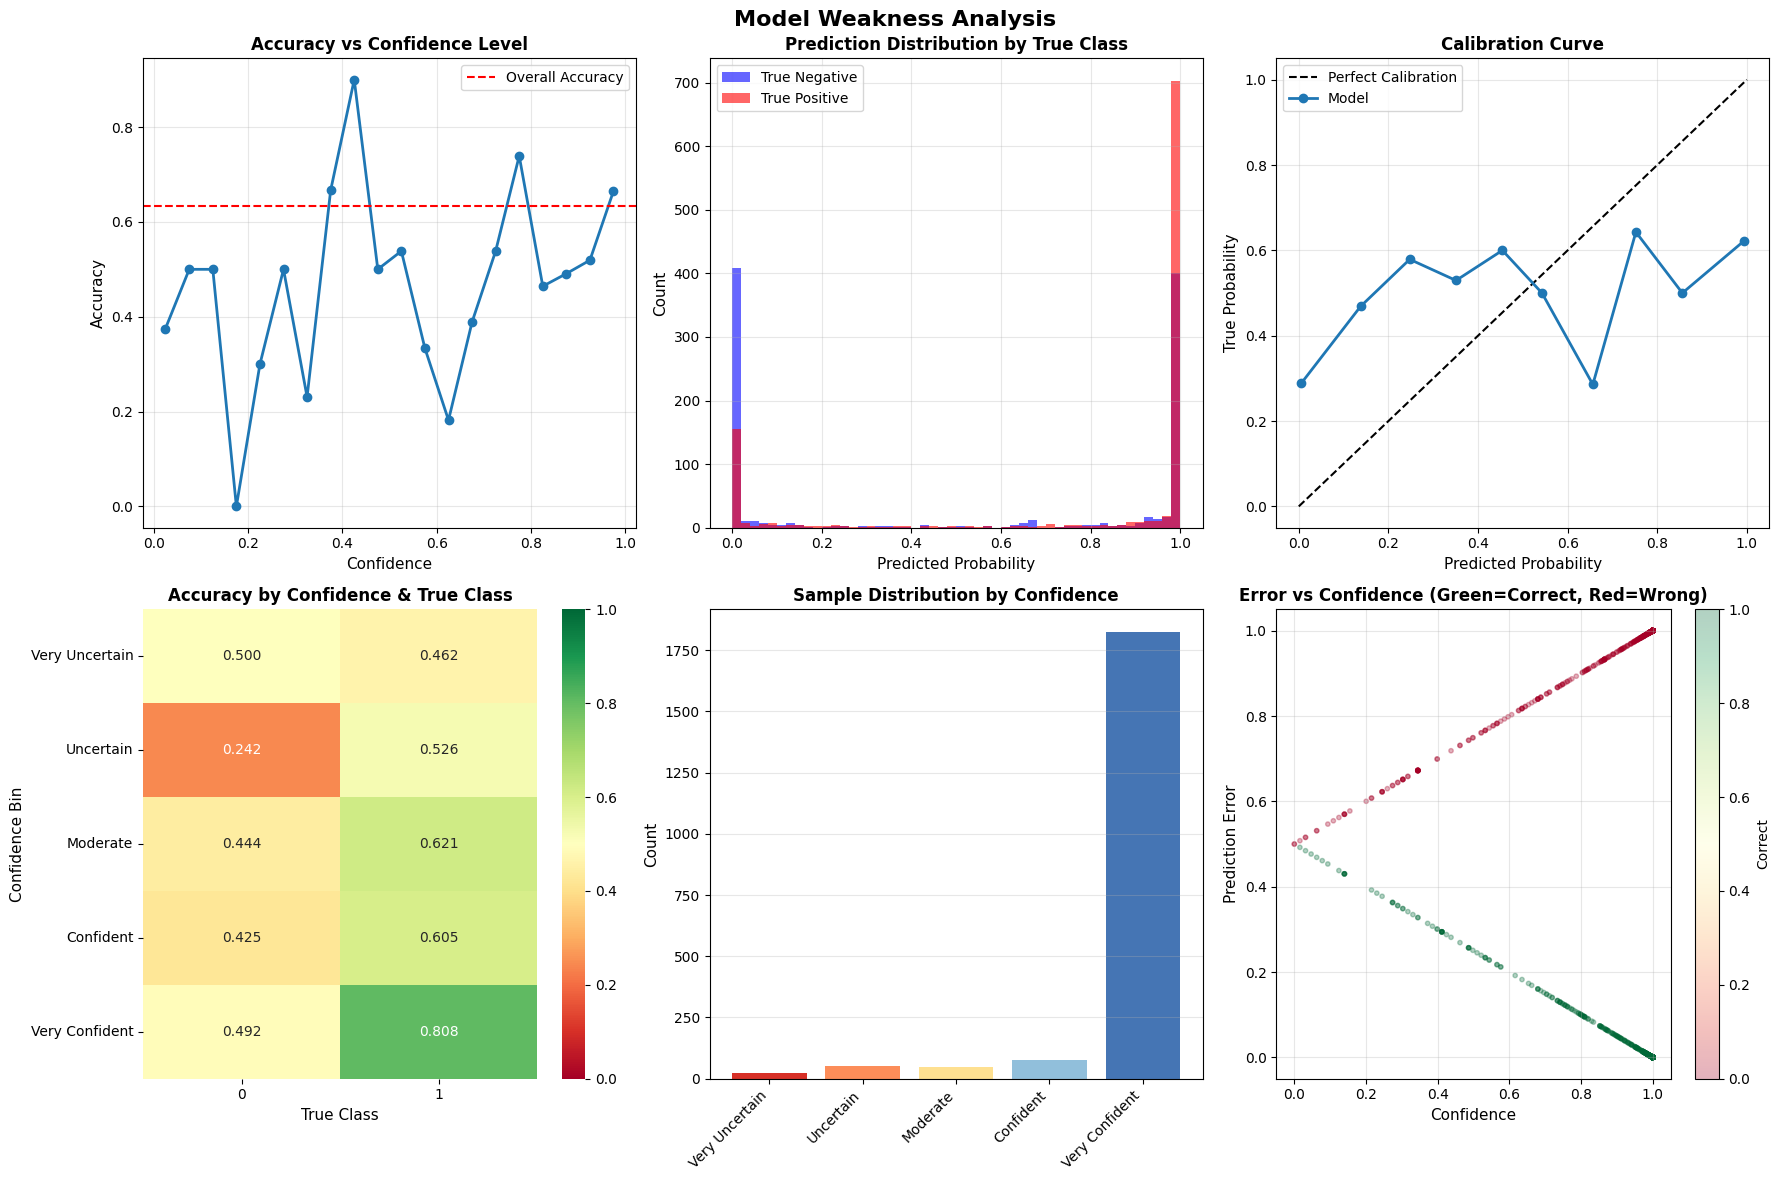


SAVING DETAILED RESULTS...

✓ Saved 'worst_predictions.csv' - top 100 worst predictions
✓ Saved 'confidently_wrong_predictions.csv' - 652 high-confidence errors
✓ Saved 'analysis_summary.csv' - key metrics summary

KEY FINDINGS:

1. Your model is confidently wrong 32.13% of the time
2. When uncertain (confidence < 0.3), accuracy is 0.4255
3. When confident (confidence > 0.7), accuracy is 0.6521
4. Calibration error: 0.2520 - Needs improvement

Consider focusing on reducing confidently wrong predictions through:
- Hard negative mining during training
- Threshold adjustment for uncertain cases
- Examining features of confidently wrong samples


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

# Assuming oof contains tuples of (predictions, targets)
# Concatenate all folds
all_preds = np.concatenate([x[0] for x in oofllm])
all_targets = np.concatenate([x[1] for x in oofllm])
# msk= (all_targets>0) & (all_targets<1)
# all_targets=all_targets[~msk]
# all_preds= all_preds[~msk]
all_targets=(all_targets>.5).astype(dtype=np.int8)
# Create analysis dataframe
df_analysis = pd.DataFrame({
    'prediction': all_preds,
    'target': all_targets,
    'confidence': np.abs(all_preds - 0.5) * 2,  # 0 = uncertain, 1 = confident
    'error': np.abs(all_preds - all_targets)
})

# Binary predictions
df_analysis['pred_class'] = (df_analysis['prediction'] > 0.5).astype(int)
df_analysis['correct'] = (df_analysis['pred_class'] == df_analysis['target']).astype(int)

print("="*80)
print("MODEL PERFORMANCE ANALYSIS")
print("="*80)

# Overall metrics
overall_auc = roc_auc_score(all_targets, all_preds)
print(f"\nOverall AUC: {overall_auc:.4f}")
print(f"Overall Accuracy: {df_analysis['correct'].mean():.4f}")

# 1. CONFIDENCE-BASED ANALYSIS
print("\n" + "="*80)
print("1. CONFIDENCE BINS ANALYSIS")
print("="*80)

# Create confidence bins
df_analysis['confidence_bin'] = pd.cut(df_analysis['confidence'], 
                                        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                        labels=['Very Uncertain', 'Uncertain', 'Moderate', 'Confident', 'Very Confident'])

confidence_stats = df_analysis.groupby('confidence_bin').agg({
    'correct': ['mean', 'count'],
    'error': 'mean',
    'target': 'mean'
}).round(4)

confidence_stats.columns = ['Accuracy', 'Count', 'Avg_Error', 'Positive_Rate']
print("\n", confidence_stats)

# 2. IDENTIFY CONFIDENTLY WRONG PREDICTIONS
print("\n" + "="*80)
print("2. CONFIDENTLY WRONG PREDICTIONS")
print("="*80)

# Define "confidently wrong" as high confidence but incorrect
confidently_wrong = df_analysis[(df_analysis['confidence'] > 0.7) & (df_analysis['correct'] == 0)]
print(f"\nTotal confidently wrong predictions: {len(confidently_wrong)} ({len(confidently_wrong)/len(df_analysis)*100:.2f}%)")

if len(confidently_wrong) > 0:
    print("\nConfidently Wrong Breakdown:")
    print(f"- False Positives (high confidence): {len(confidently_wrong[confidently_wrong['pred_class'] == 1])}")
    print(f"- False Negatives (high confidence): {len(confidently_wrong[confidently_wrong['pred_class'] == 0])}")
    print(f"- Average confidence of wrong predictions: {confidently_wrong['confidence'].mean():.4f}")

# 3. ANALYZE UNCERTAIN PREDICTIONS
print("\n" + "="*80)
print("3. UNCERTAIN PREDICTIONS ANALYSIS")
print("="*80)

uncertain = df_analysis[df_analysis['confidence'] < 0.3]
print(f"\nTotal uncertain predictions: {len(uncertain)} ({len(uncertain)/len(df_analysis)*100:.2f}%)")
print(f"Accuracy when uncertain: {uncertain['correct'].mean():.4f}")
print(f"Positive class rate when uncertain: {uncertain['target'].mean():.4f}")

# 4. ERROR ANALYSIS BY PREDICTION RANGE
print("\n" + "="*80)
print("4. ERROR PATTERNS BY PREDICTION RANGE")
print("="*80)

df_analysis['pred_range'] = pd.cut(df_analysis['prediction'], 
                                     bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                     labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

range_stats = df_analysis.groupby('pred_range').agg({
    'correct': ['mean', 'count'],
    'target': 'mean'
}).round(4)

range_stats.columns = ['Accuracy', 'Count', 'True_Positive_Rate']
print("\n", range_stats)

# 5. CALIBRATION ANALYSIS
print("\n" + "="*80)
print("5. CALIBRATION ANALYSIS")
print("="*80)

prob_true, prob_pred = calibration_curve(all_targets, all_preds, n_bins=10)
calibration_error = np.mean(np.abs(prob_true - prob_pred))
print(f"\nExpected Calibration Error (ECE): {calibration_error:.4f}")
print("(Lower is better - measures if predicted probabilities match true probabilities)")

# 6. CONFUSION MATRIX ANALYSIS
print("\n" + "="*80)
print("6. CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(all_targets, df_analysis['pred_class'])
print("\n", pd.DataFrame(cm, 
                         columns=['Pred Negative', 'Pred Positive'],
                         index=['True Negative', 'True Positive']))

# 7. DETAILED CLASSIFICATION REPORT
print("\n" + "="*80)
print("7. CLASSIFICATION REPORT")
print("="*80)
print("\n", classification_report(all_targets, df_analysis['pred_class'], 
                                   target_names=['Negative', 'Positive']))

# VISUALIZATION SECTION
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Weakness Analysis', fontsize=16, fontweight='bold')

# Plot 1: Confidence vs Accuracy
ax1 = axes[0, 0]
conf_acc = df_analysis.groupby(pd.cut(df_analysis['confidence'], bins=20))['correct'].mean()
conf_bins = [interval.mid for interval in conf_acc.index]
ax1.plot(conf_bins, conf_acc.values, marker='o', linewidth=2)
ax1.set_xlabel('Confidence', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy vs Confidence Level', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=df_analysis['correct'].mean(), color='r', linestyle='--', label='Overall Accuracy')
ax1.legend()

# Plot 2: Prediction Distribution
ax2 = axes[0, 1]
ax2.hist(df_analysis[df_analysis['target']==0]['prediction'], bins=50, alpha=0.6, label='True Negative', color='blue')
ax2.hist(df_analysis[df_analysis['target']==1]['prediction'], bins=50, alpha=0.6, label='True Positive', color='red')
ax2.set_xlabel('Predicted Probability', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Prediction Distribution by True Class', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Calibration Curve
ax3 = axes[0, 2]
ax3.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax3.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax3.set_xlabel('Predicted Probability', fontsize=11)
ax3.set_ylabel('True Probability', fontsize=11)
ax3.set_title('Calibration Curve', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Error Heatmap
ax4 = axes[1, 0]
error_matrix = df_analysis.pivot_table(values='correct', 
                                        index='confidence_bin', 
                                        columns='target', 
                                        aggfunc='mean')
sns.heatmap(error_matrix, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Accuracy by Confidence & True Class', fontsize=12, fontweight='bold')
ax4.set_ylabel('Confidence Bin', fontsize=11)
ax4.set_xlabel('True Class', fontsize=11)

# Plot 5: Count by Confidence Bin
ax5 = axes[1, 1]
confidence_counts = df_analysis['confidence_bin'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
ax5.bar(range(len(confidence_counts)), confidence_counts.values, color=colors)
ax5.set_xticks(range(len(confidence_counts)))
ax5.set_xticklabels(confidence_counts.index, rotation=45, ha='right')
ax5.set_ylabel('Count', fontsize=11)
ax5.set_title('Sample Distribution by Confidence', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Error vs Confidence Scatter
ax6 = axes[1, 2]
scatter = ax6.scatter(df_analysis['confidence'], 
                      df_analysis['error'], 
                      c=df_analysis['correct'], 
                      cmap='RdYlGn', 
                      alpha=0.3, 
                      s=10)
ax6.set_xlabel('Confidence', fontsize=11)
ax6.set_ylabel('Prediction Error', fontsize=11)
ax6.set_title('Error vs Confidence (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax6, label='Correct')

plt.tight_layout()
plt.show()

# SAVE DETAILED ANALYSIS
print("\n" + "="*80)
print("SAVING DETAILED RESULTS...")
print("="*80)

# Export worst predictions
worst_predictions = df_analysis.nlargest(100, 'error')[['prediction', 'target', 'confidence', 'error', 'correct']]
worst_predictions.to_csv('worst_predictions.csv', index=False)
print("\n✓ Saved 'worst_predictions.csv' - top 100 worst predictions")

# Export confidently wrong
confidently_wrong.to_csv('confidently_wrong_predictions.csv', index=False)
print(f"✓ Saved 'confidently_wrong_predictions.csv' - {len(confidently_wrong)} high-confidence errors")

# Summary statistics
summary = {
    'Overall_AUC': overall_auc,
    'Overall_Accuracy': df_analysis['correct'].mean(),
    'Calibration_Error': calibration_error,
    'Pct_Confidently_Wrong': len(confidently_wrong)/len(df_analysis)*100,
    'Pct_Uncertain': len(uncertain)/len(df_analysis)*100,
    'Accuracy_When_Confident': df_analysis[df_analysis['confidence'] > 0.7]['correct'].mean(),
    'Accuracy_When_Uncertain': uncertain['correct'].mean()
}

pd.DataFrame([summary]).to_csv('analysis_summary.csv', index=False)
print("✓ Saved 'analysis_summary.csv' - key metrics summary")

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"\n1. Your model is confidently wrong {len(confidently_wrong)/len(df_analysis)*100:.2f}% of the time")
print(f"2. When uncertain (confidence < 0.3), accuracy is {uncertain['correct'].mean():.4f}")
print(f"3. When confident (confidence > 0.7), accuracy is {df_analysis[df_analysis['confidence'] > 0.7]['correct'].mean():.4f}")
print(f"4. Calibration error: {calibration_error:.4f} - {'Good' if calibration_error < 0.1 else 'Needs improvement'}")
print("\nConsider focusing on reducing confidently wrong predictions through:")
print("- Hard negative mining during training")
print("- Threshold adjustment for uncertain cases")
print("- Examining features of confidently wrong samples")

In [56]:
sml

,rule,body,text,preds
0,"No Advertising: Spam, referral links, unsolici...",Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",1.000000e+00
1,"No Advertising: Spam, referral links, unsolici...",SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",8.677781e-09
2,No legal advice: Do not offer or request legal...,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,5.430416e-09
3,"No Advertising: Spam, referral links, unsolici...",she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",1.000000e+00
4,"No Advertising: Spam, referral links, unsolici...",code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",1.000000e+00
...,...,...,...,...
2024,No legal advice: Do not offer or request legal...,Please edit your post so it is readable. These...,No legal advice: Do not offer or request legal...,2.814056e-01
2025,No legal advice: Do not offer or request legal...,"Yes, and in a right to work state they can eve...",No legal advice: Do not offer or request legal...,8.664654e-06
2026,"No Advertising: Spam, referral links, unsolici...",**HD** Streams: |ENG **HD**[ Watch here..PC & ...,"No Advertising: Spam, referral links, unsolici...",2.868540e-04
2027,No legal advice: Do not offer or request legal...,No. Not when doing so obviously presents a saf...,No legal advice: Do not offer or request legal...,8.991214e-01


In [57]:
sml=df[['rule','body']].copy()
sml['text']= sml["rule"] + " [SEP] " + sml["body"]
sml['preds']= oofllm[0][0].tolist()
sml=sml.groupby(sml.text.str.lower(),as_index=False).agg({
    'text': 'first',  # Keep the original case of the first occurrence
    'preds': 'mean'   # Take mean of labels
})
sml.shape

(1875, 2)

In [61]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from itertools import product

def blend_oofs_grid_search(oofs_dict, y_true, step=0.05, normalize=True):
    """
    Find optimal weights for blending multiple OOF predictions using grid search.
    
    Parameters:
    -----------
    oofs_dict : dict
        Dictionary with model names as keys and OOF predictions as values
        Example: {'model1': oof1_array, 'model2': oof2_array, ...}
    y_true : array-like
        True target values (must be aligned with OOF predictions)
    step : float
        Grid search step size for weights (default: 0.05 for 5% increments)
    normalize : bool
        Whether to normalize weights to sum to 1 (default: True)
    
    Returns:
    --------
    dict with keys:
        - 'best_weights': dictionary of optimal weights
        - 'best_auc': best AUC score achieved
        - 'best_blend': blended predictions using best weights
        - 'results_df': DataFrame with all tested combinations
    """
    
    model_names = list(oofs_dict.keys())
    n_models = len(model_names)
    
    print(f"Grid searching optimal weights for {n_models} models...")
    print(f"Step size: {step}")
    
    # Generate weight combinations
    if normalize:
        # Generate weights that sum to 1
        weights_range = np.arange(0, 1 + step, step)
        weight_combinations = []
        
        # Generate all combinations and filter those that sum to ~1
        for weights in product(weights_range, repeat=n_models):
            if abs(sum(weights) - 1.0) < 1e-6:  # Account for floating point errors
                weight_combinations.append(weights)
    else:
        # Generate independent weights
        weights_range = np.arange(0, 1 + step, step)
        weight_combinations = list(product(weights_range, repeat=n_models))
    
    print(f"Testing {len(weight_combinations)} weight combinations...")
    
    # Store results
    results = []
    best_auc = -1
    best_weights = None
    best_blend = None
    
    # Convert OOFs to numpy arrays
    oofs_arrays = [np.array(oofs_dict[name]) for name in model_names]
    y_true = np.array(y_true)
    
    # Test each combination
    for i, weights in enumerate(weight_combinations):
        # Blend predictions
        blended = np.zeros_like(oofs_arrays[0], dtype=float)
        for oof, w in zip(oofs_arrays, weights):
            blended += w * oof
        
        # Calculate AUC
        try:
            auc = roc_auc_score(y_true, blended)
            
            # Store result
            result = {name: w for name, w in zip(model_names, weights)}
            result['auc'] = auc
            results.append(result)
            
            # Update best
            if auc > best_auc:
                best_auc = auc
                best_weights = dict(zip(model_names, weights))
                best_blend = blended.copy()
        
        except Exception as e:
            print(f"Error with weights {weights}: {e}")
            continue
        
        # Progress update
        if (i + 1) % 1000 == 0:
            print(f"Processed {i + 1}/{len(weight_combinations)} combinations. Best AUC so far: {best_auc:.6f}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('auc', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*60)
    print("BEST COMBINATION FOUND:")
    print("="*60)
    for name, weight in best_weights.items():
        print(f"{name}: {weight:.3f}")
    print(f"\nBest AUC: {best_auc:.6f}")
    print("="*60)
    
    # Show top 10 combinations
    print("\nTop 10 Weight Combinations:")
    print(results_df.head(10).to_string(index=False))
    
    return {
        'best_weights': best_weights,
        'best_auc': best_auc,
        'best_blend': best_blend,
        'results_df': results_df
    }



# Example usage
if __name__ == "__main__":
    # Example: Generate synthetic data
    # np.random.seed(42)
    # n_samples = 1000
    
    # True labels
    y_true = all_targets

    oof1= bert_preds
    oof2= sml.preds
    
    # Create dictionary of OOFs
    oofs = {
        'deberta': oof1,
        'llm': oof2,
    }
    
    # Individual model AUCs
    print("Individual Model AUCs:")
    for name, oof in oofs.items():
        auc = roc_auc_score(y_true, oof)
        print(f"{name}: {auc:.6f}")
    print()
    
    # Run grid search
    results = blend_oofs_grid_search(
        oofs_dict=oofs,
        y_true=y_true,
        step=0.05,  # Use 0.05 or 0.025 for finer search
        normalize=True
    )
    
    # Access results
    best_weights = results['best_weights']
    best_auc = results['best_auc']
    best_blend = results['best_blend']
    results_df = results['results_df']

Individual Model AUCs:
deberta: 0.848331
llm: 0.707550

Grid searching optimal weights for 2 models...
Step size: 0.05
Testing 21 weight combinations...

BEST COMBINATION FOUND:
deberta: 0.950
llm: 0.050

Best AUC: 0.850212

Top 10 Weight Combinations:
 deberta  llm      auc
    0.95 0.05 0.850212
    0.90 0.10 0.849185
    1.00 0.00 0.848331
    0.85 0.15 0.847459
    0.80 0.20 0.845896
    0.75 0.25 0.844554
    0.70 0.30 0.843093
    0.65 0.35 0.839920
    0.60 0.40 0.836116
    0.55 0.45 0.829053


In [45]:
len(oofllm[0][0])

2029

In [ ]:
all_targets.shape

In [ ]:
if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    # Generate final predictions using Stage 2 models
    print("=== Generating final predictions ===")
    
    sample = pd.read_csv(sample_sub_path)
    df_test = pd.read_csv(test_path)
    df_test["text"] = df_test["rule"] + " [SEP] " + df_test["body"]
    
    test_preds = []
    for fold in range(NFOLDS):
        model = JigsawModel(MODEL_PATH2).to(DEVICE)
        model.load_state_dict(torch.load(f"model_fold{fold}_stage1.bin", map_location=DEVICE))
        model= nn.DataParallel(model)

        model.eval()
    
        test_ds = JigsawDataset(df_test['text'].tolist(), [0]*len(df_test), [0]*len(df_test), tokenizer, MAX_LEN)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
    
        fold_preds = []
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Predicting fold {fold}"):
                ids = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                logits = model(ids, mask)
                fold_preds.extend(torch.sigmoid(logits).cpu().numpy())
        
        test_preds.append(fold_preds)
        del model
        torch.cuda.empty_cache()

In [ ]:
if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    final_preds = np.mean(test_preds, axis=0)
    sample["rule_violation"] = final_preds
    sample.to_csv("submission.csv", index=False)
    print("✅ Submission saved as submission.csv")
else:
    !touch submission.csv
    
!head -n 4 submission.csv